# Lab 8


## Setup for SUSY Dataset

Use the SUSY dataset for the rest of this lab. Here is a basic setup.

In [1]:
# Our usual libraries...
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import HTML, display
import tabulate

In [2]:
filename="../Lab.7/SUSY.csv"
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", 
          "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET",
          "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]
df = pd.read_csv(filename, dtype='float64', names=VarNames)

## Scikit-Learn

[Scikit-learn](http://scikit-learn.org) is a rich python library for data science, including machine learning. For example, we can build a Fisher Discriminant (aka Linear Discriminant Analysis, or LDA). 

### Exercise 1: Install Scikit-Learn

Follow the [Installation Instructions](https://scikit-learn.org/stable/install.html) and install `scikit-learn` in your environment.

### Exercise 2: Read About Classifiers

#### Part a
Scikit-learn offers an impressively comprehensive list of machine learning algorithms. Browse through [scikit-learn's documentation](https://scikit-learn.org/stable/index.html). You'll note the algorithms are organized into classification, regression, clustering, dimensionality reduction, model selection, and preprocessing. Browse through the list of [classification algorithms](https://scikit-learn.org/stable/supervised_learning.html#supervised-learning). 

#### Part b
Note scikit-learn's documentation is rather comprehensive. The documentation on [linear models](https://scikit-learn.org/stable/modules/linear_model.html) shows how classification problems are setup. Read about the first few methods and try to comprehend the example codes. Skim the rest of the document.

#### Part c
Read through the [LDA Documentation](https://scikit-learn.org/stable/modules/lda_qda.html).


### Exercise 3: Training a Classifier

Lets' repeat what we did manually in the previous lab using scikit-learn. We'll use a LDA classifier, which we can instanciate as follows:

In [3]:
import sklearn.discriminant_analysis as DA
Fisher=DA.LinearDiscriminantAnalysis()

As discussed in the lecture, to properly formulate our problem, we'll have to:

* Define the inputs (X) vs outputs (Y)
* Designate training vs testing samples (in order to get a unbias assessment of the performance of Machine Learning algorithms)

for example, here we'll take use 4M events for training and the remainder for testing.

In [4]:
N_Train=4000000

Train_Sample=df[:N_Train]
Test_Sample=df[N_Train:]

X_Train=Train_Sample[VarNames[1:]]
y_Train=Train_Sample["signal"]

X_Test=Test_Sample[VarNames[1:]]
y_Test=Test_Sample["signal"]

Test_sig=Test_Sample[Test_Sample.signal==1]
Test_bkg=Test_Sample[Test_Sample.signal==0]


We can train the classifier as follow:

In [5]:
Fisher.fit(X_Train,y_Train)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


We can plot the output, comparing signal and background:

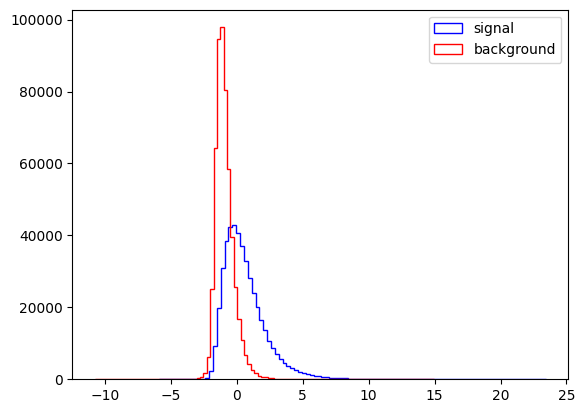

In [6]:
plt.figure()
plt.hist(Fisher.decision_function(Test_sig[VarNames[1:]]),bins=100,histtype="step", color="blue", label="signal",stacked=True)
plt.hist(Fisher.decision_function(Test_bkg[VarNames[1:]]),bins=100,histtype="step", color="red", label="background",stacked=True)
plt.legend(loc='upper right')
plt.show()

#### Part a

Compare ROC curves computed on the test versus training samples, in a single plot. Do you see a bias?

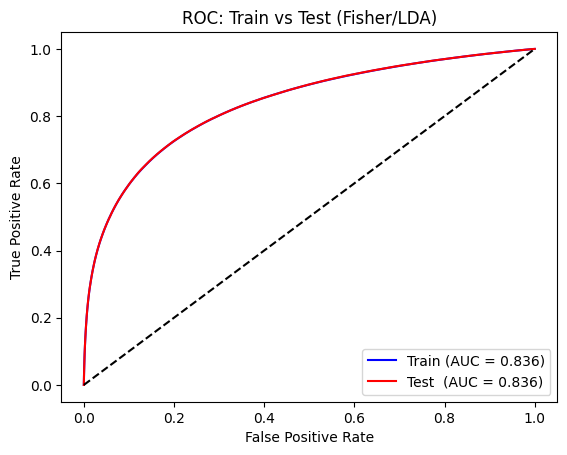

In [7]:
from sklearn.metrics import roc_curve, auc

# First we get decision scores on both training and test sets
train_scores = Fisher.decision_function(X_Train)
test_scores  = Fisher.decision_function(X_Test)

# Then we compute ROC curves for each
fpr_train, tpr_train, _ = roc_curve(y_Train, train_scores)
fpr_test,  tpr_test,  _ = roc_curve(y_Test,  test_scores)

# Then compute AUC for each
auc_train = auc(fpr_train, tpr_train)
auc_test  = auc(fpr_test,  tpr_test)

# Overlaying both of the curves on a single plot
plt.figure()
plt.plot(fpr_train, tpr_train, color="blue", label="Train (AUC = %.3f)" % auc_train)
plt.plot(fpr_test,  tpr_test,  color="red",  label="Test  (AUC = %.3f)" % auc_test)
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC: Train vs Test (Fisher/LDA)")
plt.legend(loc="lower right")
plt.show()

# The two curves largely overlap, indicating no significant bias / overfitting.
# LDA is a low-variance linear model and 4M training events is more than sufficient.

#### Part b

Train the Fisher performance of using the raw, features, and raw+features as input. Compare the performance one a single plot. 

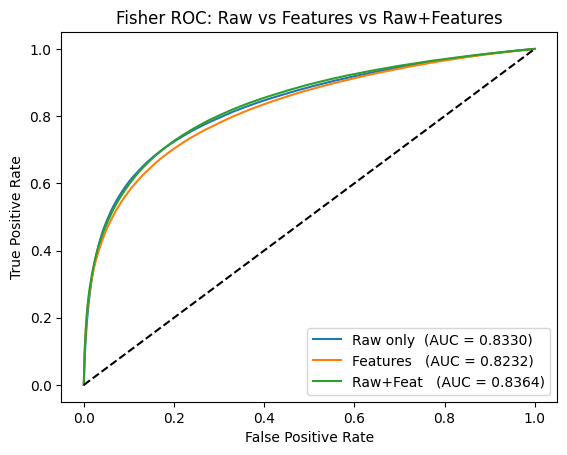

In [8]:
# Defining the 3 input sets
RawNames     = ["l_1_pT", "l_1_eta", "l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames = list(set(VarNames[1:]).difference(RawNames))

X_Train_raw  = Train_Sample[RawNames]
X_Test_raw   = Test_Sample[RawNames]

X_Train_feat = Train_Sample[FeatureNames]
X_Test_feat  = Test_Sample[FeatureNames]

X_Train_all  = Train_Sample[VarNames[1:]]
X_Test_all   = Test_Sample[VarNames[1:]]

# Training a separate Fisher discriminant for each input set
Fisher_raw  = DA.LinearDiscriminantAnalysis()
Fisher_feat = DA.LinearDiscriminantAnalysis()
Fisher_all  = DA.LinearDiscriminantAnalysis()

Fisher_raw.fit(X_Train_raw,   y_Train)
Fisher_feat.fit(X_Train_feat, y_Train)
Fisher_all.fit(X_Train_all,   y_Train)

# Computing ROC curves on the test set
fpr_raw,  tpr_raw,  _ = roc_curve(y_Test, Fisher_raw.decision_function(X_Test_raw))
fpr_feat, tpr_feat, _ = roc_curve(y_Test, Fisher_feat.decision_function(X_Test_feat))
fpr_all,  tpr_all,  _ = roc_curve(y_Test, Fisher_all.decision_function(X_Test_all))

auc_raw  = auc(fpr_raw,  tpr_raw)
auc_feat = auc(fpr_feat, tpr_feat)
auc_all  = auc(fpr_all,  tpr_all)

# Overlaying all 3 into a single plot
plt.figure()
plt.plot(fpr_raw,  tpr_raw,  label="Raw only  (AUC = %.4f)" % auc_raw)
plt.plot(fpr_feat, tpr_feat, label="Features   (AUC = %.4f)" % auc_feat)
plt.plot(fpr_all,  tpr_all,  label="Raw+Feat   (AUC = %.4f)" % auc_all)
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Fisher ROC: Raw vs Features vs Raw+Features")
plt.legend(loc="lower right")
plt.show()

### Exercise 4: Comparing Techniques

#### Part a
Select 3 different classifiers from the techniques listed [here](http://scikit-learn.org/stable/supervised_learning.html#supervised-learning) to compare. Note that you can use the multi-layer perceptron to build a deep network, though training may be prohibitively slow. So avoid this technique.

#### Part b

Write a function that takes an instantiated classifier and performs the comparison from part 3b. Use the function on your choice of functions in part a.

#### Part c

Use the best method from part c to compute the maximal significance $\sigma_S= \frac{N_S}{\sqrt{N_S+N_B}}$ for the scenarios in lab 6.

In [9]:
# 3 classifiers I chose for comparison:
#   1. Logistic Regression  – linear baseline
#   2. Decision Tree        – simple non-linear model, fast to train
#   3. Random Forest        – ensemble of trees, typically stronger than a single tree

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

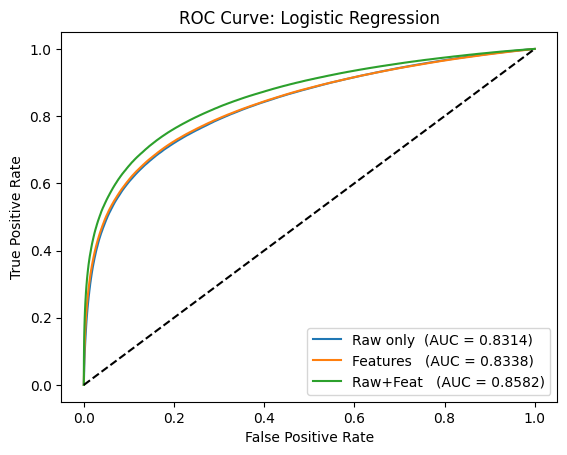

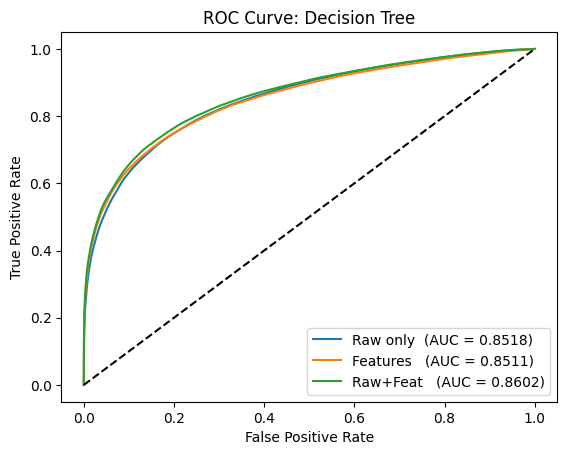

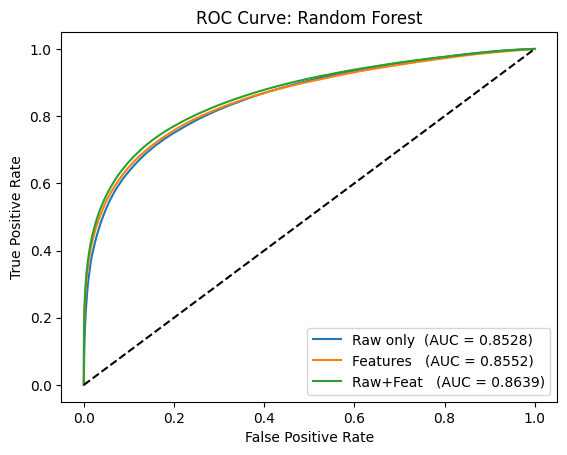

In [10]:
def compare_inputs(clf_class, clf_kwargs={}, title=""):
    """
    Trains clf_class on raw, features, and raw+features input sets,
    then overlays three ROC curves on a single plot.
    Returns a dict with the trained classifiers and their AUC values.
    """
    # Training a fresh classifier for each input set
    clf_raw  = clf_class(**clf_kwargs)
    clf_feat = clf_class(**clf_kwargs)
    clf_all  = clf_class(**clf_kwargs)

    clf_raw.fit(X_Train_raw,   y_Train)
    clf_feat.fit(X_Train_feat, y_Train)
    clf_all.fit(X_Train_all,   y_Train)

    def get_scores(clf, X):
        # Use decision_function when available, otherwise predict_proba for the signal class
        if hasattr(clf, "decision_function"):
            return clf.decision_function(X)
        return clf.predict_proba(X)[:, 1]

    # Computing ROC and AUC on the test set for each input set
    fpr_raw,  tpr_raw,  _ = roc_curve(y_Test, get_scores(clf_raw,  X_Test_raw))
    fpr_feat, tpr_feat, _ = roc_curve(y_Test, get_scores(clf_feat, X_Test_feat))
    fpr_all,  tpr_all,  _ = roc_curve(y_Test, get_scores(clf_all,  X_Test_all))

    auc_raw  = auc(fpr_raw,  tpr_raw)
    auc_feat = auc(fpr_feat, tpr_feat)
    auc_all  = auc(fpr_all,  tpr_all)

    plt.figure()
    plt.plot(fpr_raw,  tpr_raw,  label="Raw only  (AUC = %.4f)" % auc_raw)
    plt.plot(fpr_feat, tpr_feat, label="Features   (AUC = %.4f)" % auc_feat)
    plt.plot(fpr_all,  tpr_all,  label="Raw+Feat   (AUC = %.4f)" % auc_all)
    plt.plot([0, 1], [0, 1], "k--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve: " + title)
    plt.legend(loc="lower right")
    plt.show()

    return {
        "raw":      clf_raw,
        "feat":     clf_feat,
        "all":      clf_all,
        "auc_raw":  auc_raw,
        "auc_feat": auc_feat,
        "auc_all":  auc_all
    }


# Runing the comparison for each 3 chosen classifiers
results_lr = compare_inputs(LogisticRegression,
                            {"max_iter": 1000},
                            title="Logistic Regression")

results_dt = compare_inputs(DecisionTreeClassifier,
                            {"max_depth": 10, "random_state": 0},
                            title="Decision Tree")

results_rf = compare_inputs(RandomForestClassifier,
                            {"n_estimators": 20, "max_depth": 10,
                             "random_state": 0, "n_jobs": -1},
                            title="Random Forest")

In [11]:
# PART c; Using the best classifier (Random Forest trained on raw+features)
best_clf = results_rf["all"]

# Getting continuous scores on the test set
if hasattr(best_clf, "decision_function"):
    scores_test = best_clf.decision_function(X_Test_all)
else:
    scores_test = best_clf.predict_proba(X_Test_all)[:, 1]

# Separating scores by true label
F_sig = scores_test[y_Test.values == 1]
F_bkg = scores_test[y_Test.values == 0]

# Scenarios from Lab 6
scenarios = [
    (10,    100),
    (100,   1000),
    (1000,  10000),
    (10000, 100000)
]

# Threshold scan grid
thresholds = np.linspace(scores_test.min(), scores_test.max(), 200)

for N_S, N_B in scenarios:
    best_sigma     = -np.inf
    best_threshold = None
    best_eps_s     = None
    best_eps_b     = None

    for t in thresholds:
        eps_s = np.sum(F_sig > t) / len(F_sig)
        eps_b = np.sum(F_bkg > t) / len(F_bkg)

        N_S_prime = eps_s * N_S
        N_B_prime = eps_b * N_B

        denom = N_S_prime + N_B_prime
        sigma = N_S_prime / np.sqrt(denom) if denom > 0 else 0

        if sigma > best_sigma:
            best_sigma     = sigma
            best_threshold = t
            best_eps_s     = eps_s
            best_eps_b     = eps_b

    print("Scenario (N_S=%d, N_B=%d)" % (N_S, N_B))
    print("  Best threshold : %.4f" % best_threshold)
    print("  epsilon_S      : %.4f" % best_eps_s)
    print("  epsilon_B      : %.4f" % best_eps_b)
    print("  Max significance: %.4f" % best_sigma)
    print()

Scenario (N_S=10, N_B=100)
  Best threshold : 0.7642
  epsilon_S      : 0.4691
  epsilon_B      : 0.0234
  Max significance: 1.7693

Scenario (N_S=100, N_B=1000)
  Best threshold : 0.7642
  epsilon_S      : 0.4691
  epsilon_B      : 0.0234
  Max significance: 5.5950

Scenario (N_S=1000, N_B=10000)
  Best threshold : 0.7642
  epsilon_S      : 0.4691
  epsilon_B      : 0.0234
  Max significance: 17.6931

Scenario (N_S=10000, N_B=100000)
  Best threshold : 0.7642
  epsilon_S      : 0.4691
  epsilon_B      : 0.0234
  Max significance: 55.9504



### Exercise 5: Metrics

Scikit-learn provides methods for computing the FPR, TPR, ROC, AUC metrics. For example:

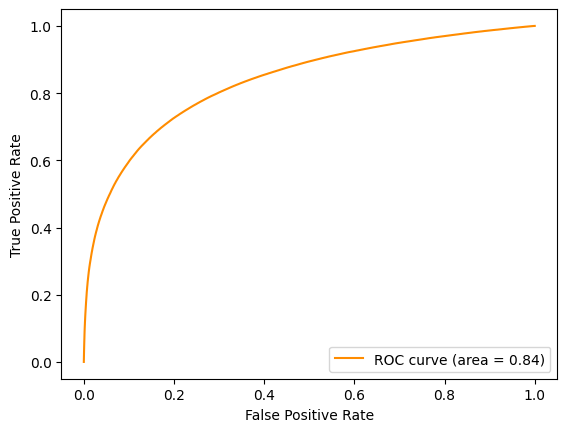

In [12]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, _ = roc_curve(y_Test, Fisher.decision_function(X_Test))

roc_auc = auc(fpr, tpr)

plt.plot(fpr,tpr,color='darkorange',label='ROC curve (area = %0.2f)' % roc_auc)
plt.legend(loc="lower right")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.show()


#### Part a
TPR/FPR/ROC/AUC are one way of assessing the quality of a classifier. Read about [Precision and Recall](https://en.wikipedia.org/wiki/Precision_and_recall), [Accuracy](https://en.wikipedia.org/wiki/Accuracy_and_precision), and [F-score](https://en.wikipedia.org/wiki/F-score).

#### Part b
Look through [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html#) documentation. Using scikit-learns tools, compute TPR, FPR, ROC, AUC, Precision, Recall, F1 score, and accuracy for the method you selected in 4c above and each scenario. Make a nice table, which also includes the maximal significance. 


In [13]:
from sklearn.metrics import (
    roc_curve, auc,
    precision_score, recall_score,
    f1_score, accuracy_score
)

# Computing the overall ROC/AUC once for the best classifier
fpr_full, tpr_full, _ = roc_curve(y_Test, scores_test)
roc_auc_full = auc(fpr_full, tpr_full)

# Building 1 table row per scenario using its optimal threshold
table_rows = []

for N_S, N_B in scenarios:
    best_sigma     = -np.inf
    best_threshold = None
    best_eps_b     = None

    for t in thresholds:
        eps_s = np.sum(F_sig > t) / len(F_sig)
        eps_b = np.sum(F_bkg > t) / len(F_bkg)

        N_S_prime = eps_s * N_S
        N_B_prime = eps_b * N_B

        denom = N_S_prime + N_B_prime
        sigma = N_S_prime / np.sqrt(denom) if denom > 0 else 0

        if sigma > best_sigma:
            best_sigma     = sigma
            best_threshold = t
            best_eps_b     = eps_b

    # Then applying the optimal threshold to get binary predictions
    y_pred = (scores_test > best_threshold).astype(int)

    # Computing TPR (= recall) using the threshold that maximises significance
    tpr_val  = recall_score(y_Test, y_pred)          # TPR = TP / (TP + FN)
    prec_val = precision_score(y_Test, y_pred)
    f1_val   = f1_score(y_Test, y_pred)
    acc_val  = accuracy_score(y_Test, y_pred)

    table_rows.append([
        "(%d, %d)" % (N_S, N_B),
        round(tpr_val,       4),   # TPR
        round(best_eps_b,    4),   # FPR at best threshold
        round(roc_auc_full,  4),   # AUC (global)
        round(prec_val,      4),
        round(tpr_val,       4),   # Recall == TPR
        round(f1_val,        4),
        round(acc_val,       4),
        round(best_sigma,    4),
        round(best_threshold, 4)
    ])

headers = [
    "Scenario (N_S, N_B)", "TPR", "FPR", "AUC",
    "Precision", "Recall", "F1 Score",
    "Accuracy", "Max Significance", "Threshold"
]

display(HTML(tabulate.tabulate(table_rows, headers=headers, tablefmt="html")))

"Scenario (N_S, N_B)",TPR,FPR,AUC,Precision,Recall,F1 Score,Accuracy,Max Significance,Threshold
"(10, 100)",0.4691,0.0234,0.8639,0.9443,0.4691,0.6268,0.7441,1.7693,0.7642
"(100, 1000)",0.4691,0.0234,0.8639,0.9443,0.4691,0.6268,0.7441,5.595,0.7642
"(1000, 10000)",0.4691,0.0234,0.8639,0.9443,0.4691,0.6268,0.7441,17.6931,0.7642
"(10000, 100000)",0.4691,0.0234,0.8639,0.9443,0.4691,0.6268,0.7441,55.9504,0.7642
